# Project: Investigate a Dataset - [TMDb_movie_data]

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
<li><a href="#Further Research">Further Research</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

> The dataset i used in this analysis is TMDb Movie Dataset, which contains information about 10,000 movies collected from The Movie Database (TMDb). The dataset provides a wide range of attributes related to movies, including financial informations, user ratings, popularity, and descriptive metadata such as cast, genres, and production companies.
This dataset is particularly suitable for my exploratory data analysis (EDA) because it includes both numerical and categorical variables, allowing me to investigation of relationships between movie characteristics and their commercial or critical success.

>  Column Descriptions:
Below is a description of each column and its significance:

<h3>Column Descriptions</h3>

<table style="width:100%; border-collapse: collapse;">
  <tr>
    <th style="border:1px solid black; padding:6px;">Column Name</th>
    <th style="border:1px solid black; padding:6px;">Description</th>
  </tr>
  <tr><td style="border:1px solid black; padding:6px;">id</td><td style="border:1px solid black; padding:6px;">Unique identifier for each movie in the dataset.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">imdb_id</td><td style="border:1px solid black; padding:6px;">Unique identifier assigned by IMDb for cross-referencing.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">popularity</td><td style="border:1px solid black; padding:6px;">A score representing the movie’s popularity based on TMDb user activity.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">budget</td><td style="border:1px solid black; padding:6px;">The production budget of the movie in original dollars.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">revenue</td><td style="border:1px solid black; padding:6px;">The total box office revenue in original dollars.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">original_title</td><td style="border:1px solid black; padding:6px;">The original title of the movie.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">cast</td><td style="border:1px solid black; padding:6px;">List of main actors involved in the movie (separated by |).</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">homepage</td><td style="border:1px solid black; padding:6px;">Official website of the movie, if available.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">director</td><td style="border:1px solid black; padding:6px;">Name of the movie director.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">tagline</td><td style="border:1px solid black; padding:6px;">Marketing tagline associated with the movie.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">keywords</td><td style="border:1px solid black; padding:6px;">Keywords describing the movie’s themes or content.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">overview</td><td style="border:1px solid black; padding:6px;">Brief summary of the movie plot.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">runtime</td><td style="border:1px solid black; padding:6px;">Duration of the movie in minutes.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">genres</td><td style="border:1px solid black; padding:6px;">Movie genres (e.g., Action, Drama), separated by |.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">production_companies</td><td style="border:1px solid black; padding:6px;">Companies that produced the movie.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">release_date</td><td style="border:1px solid black; padding:6px;">Official release date of the movie.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">vote_count</td><td style="border:1px solid black; padding:6px;">Number of user votes submitted for the movie.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">vote_average</td><td style="border:1px solid black; padding:6px;">Average user rating (scale 0–10).</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">release_year</td><td style="border:1px solid black; padding:6px;">Year the movie was released.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">budget_adj</td><td style="border:1px solid black; padding:6px;">Inflation-adjusted budget in 2010 dollars.</td></tr>
  <tr><td style="border:1px solid black; padding:6px;">revenue_adj</td><td style="border:1px solid black; padding:6px;">Inflation-adjusted revenue in 2010 dollars.</td></tr>
</table>


### Question(s) for Analysis

> Based on the TMDb movie dataset containing 10,000 movies, I will investigate the following research questions:
- How does budget influence revenue? Is there a strong correlation?
- Do certain genres generate higher revenues than others?
- Has the relationship between budget and revenue changed over different time periods (decades)?
- What is the optimal runtime for maximizing revenue?

> Dependent Variable: 
- Revenue (revenue_adj - inflation-adjusted)
  
> Independent Variables:
- Budget (budget_adj - inflation-adjusted)
- Genres
- Release year / Decade
- Runtime

In [6]:
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline

<a id='wrangling'></a>
## Data Wrangling

In [7]:
mo_data = pd.read_csv('Database_TMDb_movie_data/tmdb-movies.csv')

In [8]:
mo_data.head(5)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [9]:
print(mo_data.shape)
print('-----------------')
print(mo_data.info())

(10866, 21)
-----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   ob

In [10]:
mo_data.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


### check for null values:

In [11]:
mo_data.isnull().sum()

id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

In [12]:
# Percentage of missing values
(mo_data.isnull().mean() * 100).sort_values(ascending=False)

homepage                72.979937
tagline                 25.989324
keywords                13.740107
production_companies     9.479109
cast                     0.699429
director                 0.404933
genres                   0.211669
imdb_id                  0.092030
overview                 0.036812
budget_adj               0.000000
release_year             0.000000
vote_average             0.000000
vote_count               0.000000
release_date             0.000000
id                       0.000000
runtime                  0.000000
original_title           0.000000
revenue                  0.000000
budget                   0.000000
popularity               0.000000
revenue_adj              0.000000
dtype: float64

### check for duplicated values:

In [13]:
mo_data.duplicated().sum()

1


### Data Cleaning
 

In [14]:
# After we see null values, we will clean our dataframe.
mo_data = mo_data.dropna()
mo_data.isnull().sum()

id                      0
imdb_id                 0
popularity              0
budget                  0
revenue                 0
original_title          0
cast                    0
homepage                0
director                0
tagline                 0
keywords                0
overview                0
runtime                 0
genres                  0
production_companies    0
release_date            0
vote_count              0
vote_average            0
release_year            0
budget_adj              0
revenue_adj             0
dtype: int64

In [15]:
# remove dupliacte values 
mo_data = mo_data.drop_duplicates()
mo_data.duplicated().sum()

0

#### Zero Values in Financial Columns

Several movies contain zero values for `budget_adj` and `revenue_adj`. These values 
likely represent missing or unreported financial information rather than true zeros.

Rows with zero budgets or revenues were removed to ensure accurate financial analysis.

In [16]:
mo_data[['budget', 'revenue','budget_adj', 'revenue_adj']].eq(0).sum()

budget         546
revenue        546
budget_adj     546
revenue_adj    546
dtype: int64

In [17]:
mo_data = mo_data[(mo_data['budget'] > 0) & (mo_data['revenue'] > 0) & (mo_data['budget_adj'] > 0) & (mo_data['revenue_adj'] > 0)]
mo_data[['budget', 'revenue','budget_adj', 'revenue_adj']].eq(0).sum()

budget         0
revenue        0
budget_adj     0
revenue_adj    0
dtype: int64

In [18]:
# change some datatypes to use it later on my analysis 
mo_data['release_date'] = pd.to_datetime(mo_data['release_date'])
mo_data['release_year'] = mo_data['release_year'].astype(int)

<a id='eda'></a>
## Exploratory Data Analysis

### Research Question 1. How does budget influence revenue? Is there a strong correlation?

A small step I added to make my code more efficient is adding functions so that our code is more readable and well-structured.

In [19]:
def format_plot(title, xlabel, ylabel, figsize=(8,6)):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.gcf().set_size_inches(figsize)
    plt.tight_layout()

In [20]:
def explode_column(m_d, column, new_name):
    return m_d[column].str.split('|').explode().rename(new_name)

### 1.1 Distribution of Revenue

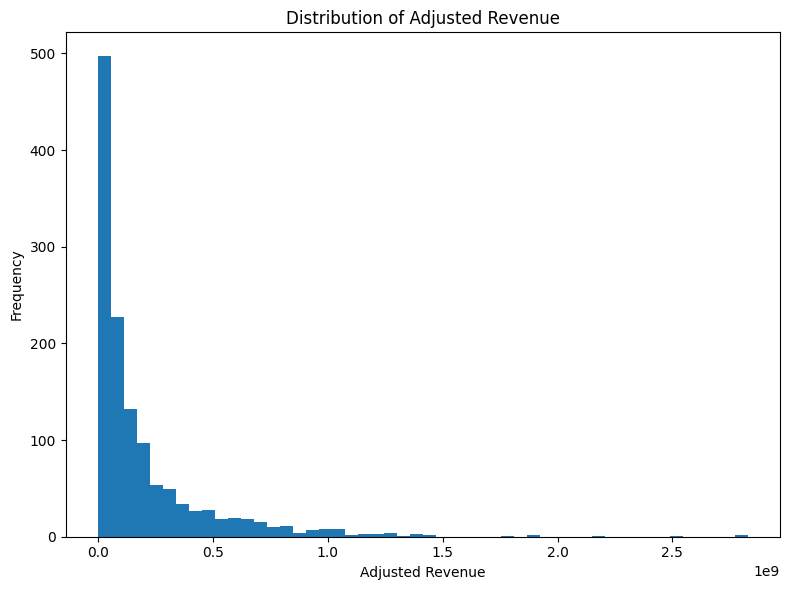

In [21]:
mo_data['revenue_adj'].plot(kind='hist', bins=50)
format_plot(title='Distribution of Adjusted Revenue', xlabel='Adjusted Revenue', ylabel='Frequency')

- The distribution is heavily skewed to the right since the majority of films make relatively little money while a few major films make extremely huge earnings.


### 1.2 Distribution of Budget

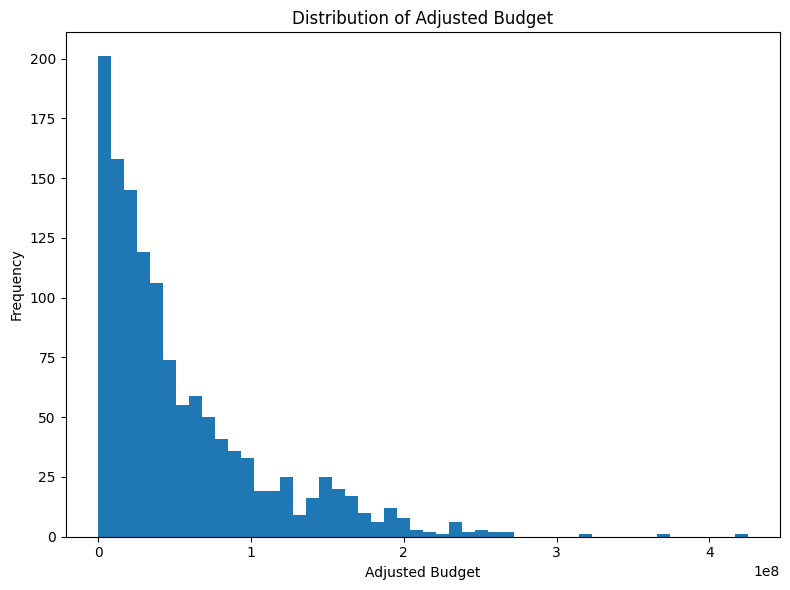

In [22]:
mo_data['budget_adj'].plot(kind='hist', bins=50)
format_plot(title='Distribution of Adjusted Budget', xlabel='Adjusted Budget', ylabel='Frequency')

- The majority of movies have reasonable costs, with very few very high-budget productions, and movie budgets are strongly skewed to the right.

### 1.3 Budget vs Revenue

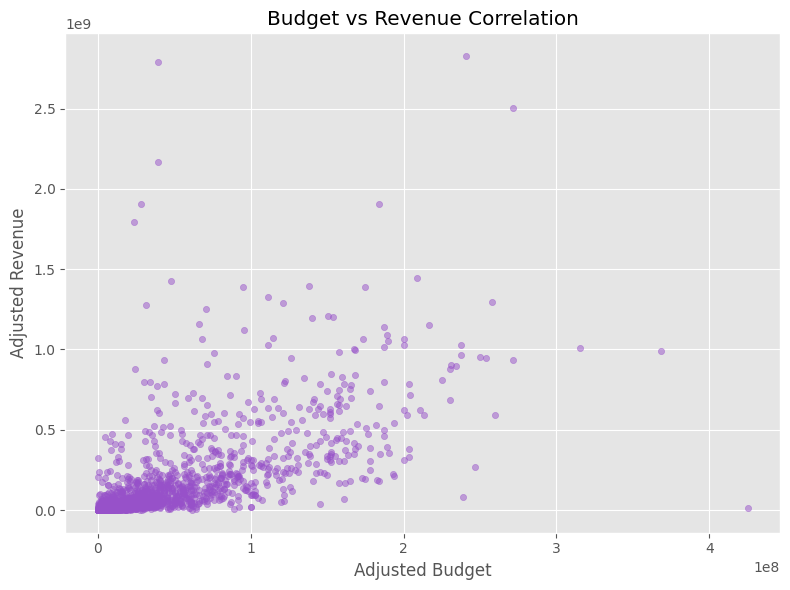

In [23]:
plt.style.use('ggplot')
mo_data.plot(x='budget_adj', y='revenue_adj', kind='scatter', alpha=0.5, color='#9751c9')
format_plot('Budget vs Revenue Correlation', 'Adjusted Budget', 'Adjusted Revenue')

- There is a similr to be positive correlation between budget and revenue. Higher-budget movies generally tend to generate higher revenue, although the relationship is not perfectly linear and contains several outliers.
- The ggplot style was applied to improve plot readability and visual clarity without affecting the underlying data or analysis results.

### Research Question 2. Do certain genres generate higher revenues than others?

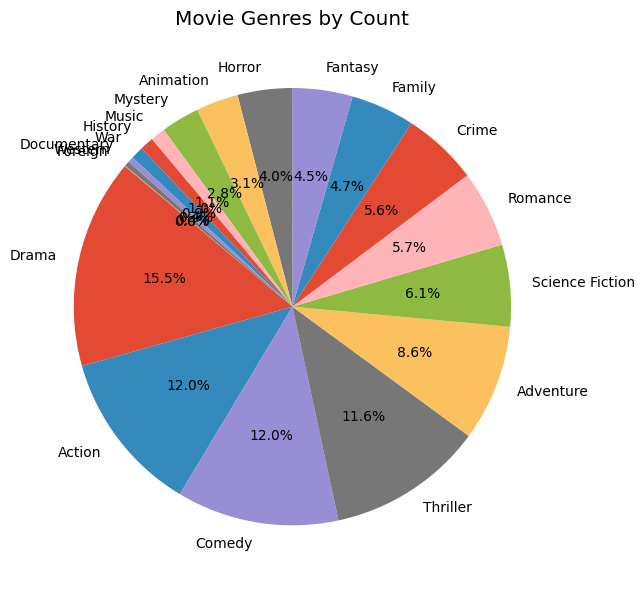

In [24]:
genres_df = explode_column(mo_data, 'genres', 'genre') # Explode genres into separate rows (19 types)

genre_counts = genres_df.value_counts()

genre_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
format_plot(title='Movie Genres by Count', xlabel ='',ylabel ='')

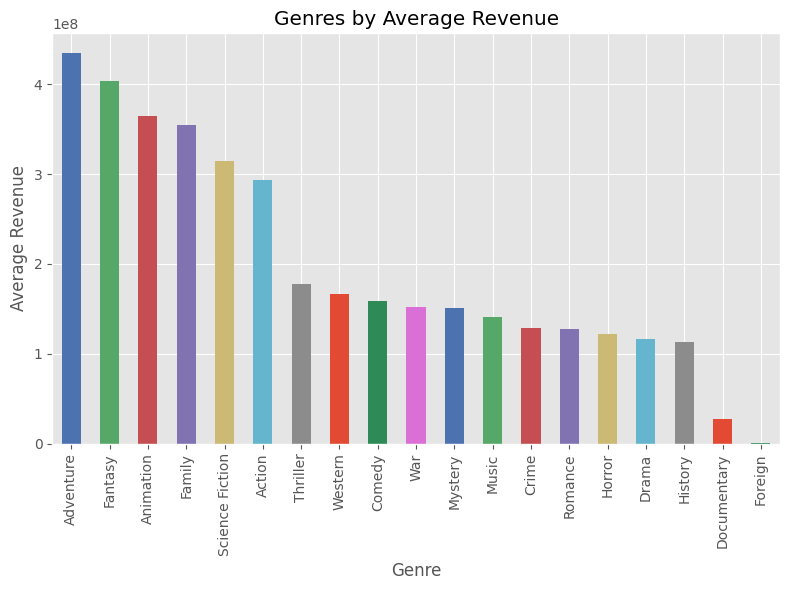

In [25]:
genre_revenue = mo_data.join(genres_df).groupby('genre')['revenue_adj'].mean().sort_values(ascending=False)
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974','#64B5CD', '#8C8C8C', '#E24A33', '#2E8B57', '#DA70D6']
genre_revenue.plot(kind='bar', color=colors)
format_plot(title='Genres by Average Revenue', xlabel='Genre', ylabel='Average Revenue')

- Adventure, Fantasy, and Animation films generate the highest average revenues, while Documentary and Foreign films earn the least on average.
- Drama, Action, and Comedy make up the largest share of movies in the dataset, while genres like Documentary, Foreign, and History represent only a small proportion.

### Research Question 3. Has the relationship between budget and revenue changed over different time periods (decades)?

In [26]:
mo_data['decade'] = (mo_data['release_year'] // 10) * 10 # Create decade column
mo_data['decade'].value_counts()

2010    604
2000    538
1990     85
1980     33
1970     19
1960      8
Name: decade, dtype: int64

In [27]:
decade_stats = mo_data.groupby('decade')[['budget_adj', 'revenue_adj']].mean() # Average budget and revenue by decade
decade_stats

,budget_adj,revenue_adj
decade,,
1960,3.194634e+07,5.124407e+08
1970,3.015674e+07,7.074008e+08
1980,4.008870e+07,3.831779e+08
1990,5.826801e+07,2.892357e+08
2000,5.526079e+07,1.750429e+08
2010,5.542081e+07,1.778118e+08


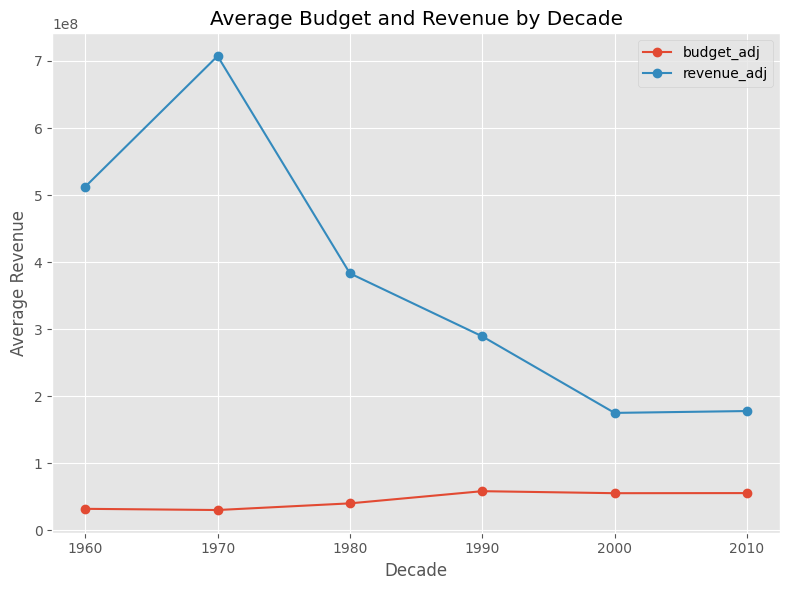

In [28]:
decade_stats.plot(kind='line', marker='o')
format_plot(title='Average Budget and Revenue by Decade', xlabel='Decade', ylabel='Average Revenue')

- Despite very modest budgets, the 1970s have a discernible peak in average revenue when compared to subsequent decades, indicating a time of exceptionally good box office performance.

### Research Question 4. What is the optimal runtime for maximizing revenue?

In [29]:
min_runtime = mo_data['runtime'].min()
max_runtime = mo_data['runtime'].max()
runtime_bins = pd.cut(mo_data['runtime'], bins=[min_runtime, 90, 120, 150, max_runtime])

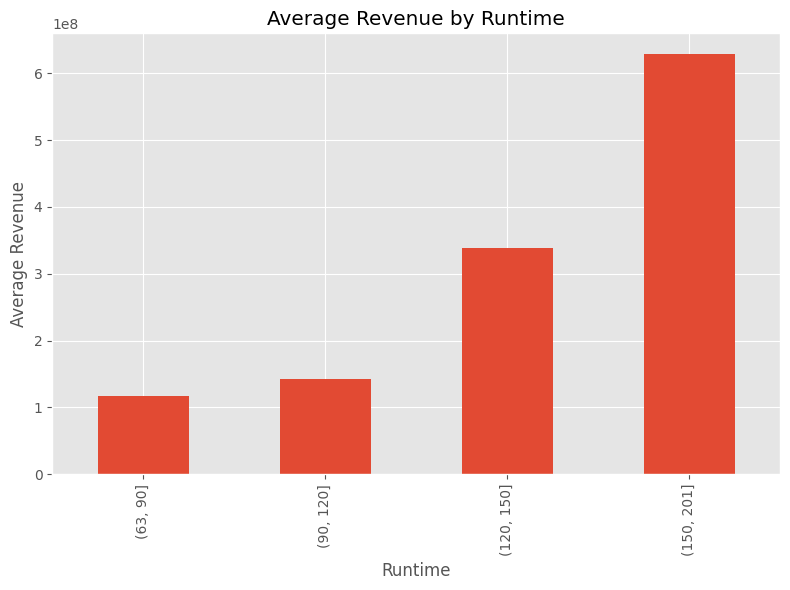

In [31]:
runtime_revenue = mo_data.groupby(runtime_bins)['revenue_adj'].mean()
runtime_revenue.plot(kind='bar')
format_plot(title='Average Revenue by Runtime', xlabel='Runtime', ylabel='Average Revenue')

- Longer films—particularly those longer than 150 minutes—generally have greater average box office receipts, though a few blockbuster movies may have an impact.

<a id='conclusions'></a>
## Conclusions

> Using the TMDb movie dataset, this analysis investigated the elements that affect a film's financial success. The main dependent variable was revenue (adjusted for inflation), whereas the independent variables were budget, genre, release decade, and runtime.

> 1. Relationship between Revenue and Budget

There is seems to be a positive relationship between budget and revenue. High-budget films generally earn substantially more than low-budget films, although several exceptions show that large investments do not always guarantee high returns.

> 2. Genre and Financial Performance

Genres differ greatly in financial outcomes. Adventure, Fantasy, and Animation films show the highest average revenues, while Documentary and Foreign films have the lowest average revenues. This highlights the strong association between genre and box office performance.

> 3. Changes Over Time (Decades)

Average movie budgets increased in the 1960s–70s and goes less in the 2000s–2010s. Revenue patterns vary by decade, with the 1970s showing particularly high average revenues compared to later decades, suggesting that industry revenue trends are not strictly linear over time.

> 4. Runtime and Revenue

Movies longer than 150 minutes have the highest average revenue, while films under 90 minutes earn much less on average. However, this may be influenced by a small number of very successful long films, meaning runtime is less consistent as a predictor than budget or genre.

> Limitations:

This analysis has several important limitations:

- 1.Correlation does not imply causation
The relationships identified show associations only and do not prove that one factor directly causes higher revenue.

- 2.Missing key variables
The dataset does not include important influences such as marketing spending, actor popularity, competition, or release timing.

- 3.Impact of outliers
A small number of blockbuster films with extremely high revenue may inflate averages, especially in the genre and runtime analyses.

<a id='Further Research'></a>
## Further Research

While this analysis identified factors associated with movie revenue, additional research could provide deeper insight into film industry success.

##### Potential Areas for Further Exploration

- 1.Movie profitability
Future studies could analyze profit (revenue minus budget) instead of revenue alone to better measure financial success.

- 2.Impact of directors and actors
Research could examine whether certain directors or cast members are consistently linked to higher revenues.

- 3.Seasonal release patterns
Investigating whether movies released during summer or holiday periods perform better could reveal timing effects.


##### Additional Information That Could Improve the Analysis

Including more detailed data could enhance future studies:

- 1.Marketing and advertising budgets —> Promotional spending strongly affects movie visibility.

- 2.Release timing and competition —> Data on release month and competing films could explain revenue differences.

- 3.International vs. domestic revenue —> Separating global earnings would provide clearer performance insights.

Incorporating these additional variables would allow for a more complete understanding of the factors influencing movie performance and support more advanced predictive analysis.

In [ ]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb